# E-Commerce Sales Performance Analysis

## Business Problem

The company wants to understand sales performance, customer behavior, product trends, and geographic performance.

## Objective

Identify patterns in sales data and provide business recommendations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [2]:
customers = pd.read_csv(
    "olist_customers_dataset.csv"
)

orders = pd.read_csv(
    "olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "olist_products_dataset.csv"
)

payments = pd.read_csv(
    "olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    "olist_order_reviews_dataset.csv"
)

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
customers.shape

(99441, 5)

In [6]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [8]:
customers.duplicated().sum()

0

In [9]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [13]:
df = (
    orders
    .merge(customers,on="customer_id")
    .merge(order_items,on="order_id")
    .merge(products,on="product_id")
    .merge(payments,on="order_id")
)

In [14]:
df["revenue"] = (
    df["price"] +
    df["freight_value"]
)

Which categories generate highest revenue?


In [15]:
category_revenue = (
    df.groupby(
        "product_category_name"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

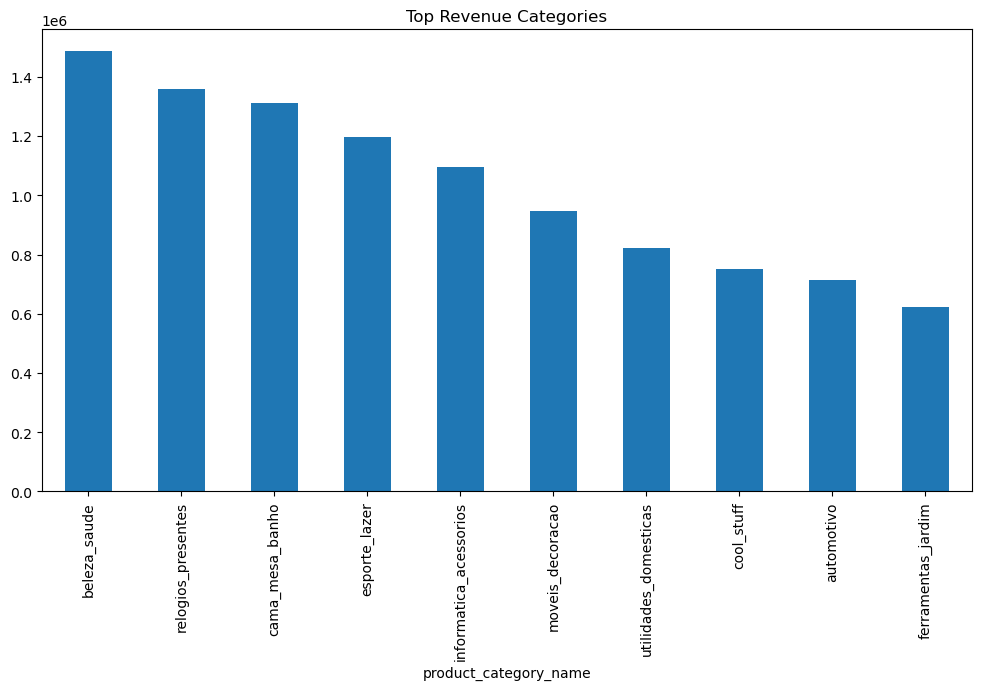

In [16]:
plt.figure(figsize=(12,6))

category_revenue.head(10).plot(
    kind="bar"
)

plt.title(
    "Top Revenue Categories"
)

plt.show()

Which cities contribute most sales?


In [17]:
city_sales = (
    df.groupby(
        "customer_city"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

Highest Value Customers

In [18]:
customer_value = (
    df.groupby(
        "customer_unique_id"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

Purchasing Patterns

In [19]:
monthly_sales = (
    df.groupby(
        df[
            "order_purchase_timestamp"
        ].dt.to_period("M")
    )["revenue"]
    .sum()
)

Top Products

In [20]:
top_products = (
    df.groupby(
        "product_id"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

Payment Method Analysis

In [21]:
payment_summary = (
    df.groupby(
        "payment_type"
    )["revenue"]
    .sum()
)

Top Sellers

In [24]:
sellers = pd.read_csv(
    "olist_sellers_dataset.csv"
)

seller_sales = (
    df.groupby(
        "seller_id"
    )["revenue"]
    .sum()
)

Review Score Analysis

In [25]:
reviews = pd.read_csv(
    "olist_order_reviews_dataset.csv"
)

review_summary = (
    reviews.groupby(
        "review_score"
    )
    .size()
)

Sales Trend

<Axes: xlabel='order_purchase_timestamp'>

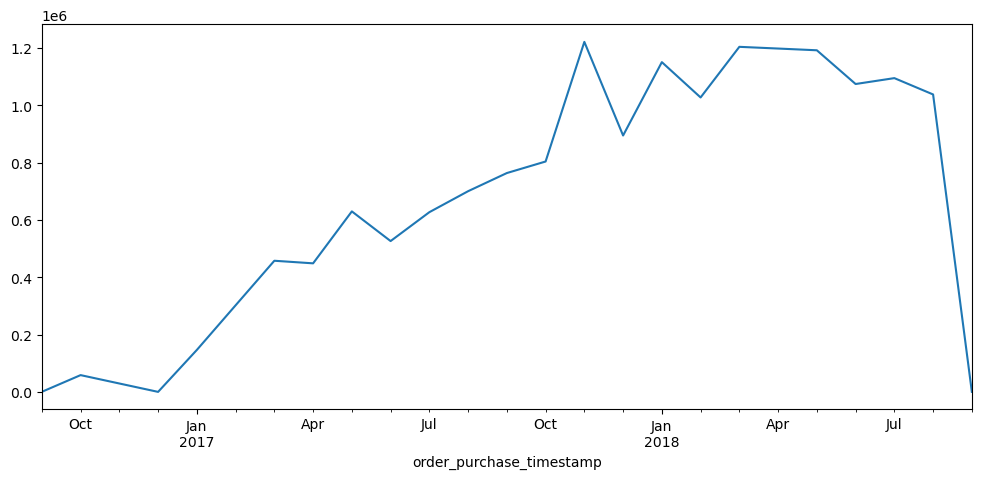

In [26]:
monthly_sales.plot(
    figsize=(12,5)
)

Repeat vs One-Time Customers

In [27]:
repeat_customers = (
    df.groupby(
        "customer_unique_id"
    )["order_id"]
    .nunique()
)

Data Quality Report

In [28]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1698
product_name_lenght              1698
product_description_lenght       1698
product_photos_qty               1698
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
payment_sequ

In [29]:
df.duplicated().sum()

0

Merge Integrity Check

In [31]:
len(orders)

99441

In [32]:
len(df)

117601

<Axes: >

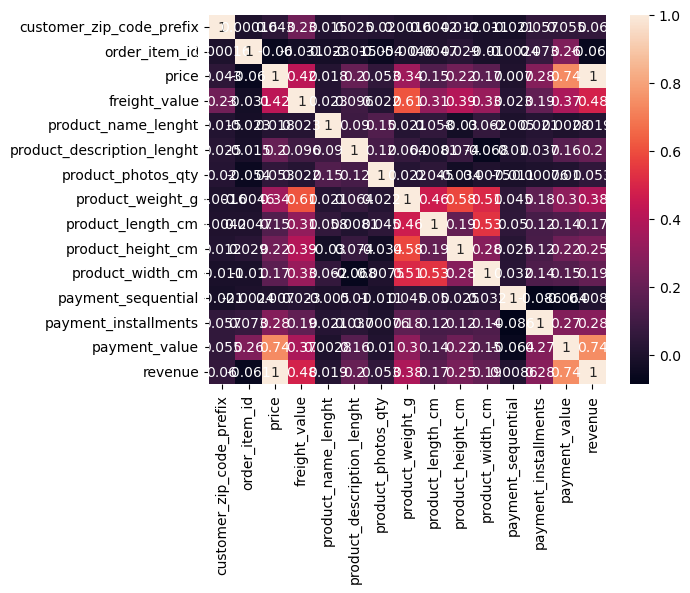

In [33]:
sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True
)